# Bank Fraud Detection

### STEP-1 IMPORTING REQUIRED LIBRARIRES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Display plots inside the notebook
%matplotlib inline

# Ignoring warning messages
import warnings
warnings.filterwarnings("ignore")

# Set plot style
plt.style.use("ggplot")
print("=" * 60)
print("All Required Libraries Imported Successfully!")
print("=" * 60)

All Required Libraries Imported Successfully!


### STEP-2 LOAD DATASET

In [3]:
df = pd.read_csv("../Dataset/fraud_dataset.csv")

print("=" * 60)
print("Dataset Loaded Successfully!")
print("=" * 60)

# Display the first five rows of the dataset
print("\nFirst Five Records of the Dataset:\n")
df.head()

Dataset Loaded Successfully!

First Five Records of the Dataset:



,transaction_id,transaction_amount,location,merchant,age,gender,fraud_label
0,1,1000.0,New York,ABC Corp,35,M,0
1,2,500.0,Chicago,XYZ Inc,45,F,0
2,3,2000.0,Los Angeles,ABC Corp,28,M,1
3,4,1500.0,San Francisco,XYZ Inc,30,F,0
4,5,800.0,Chicago,ABC Corp,50,F,0


### STEP-3 UNDERSTANDING THE DATASET

In [12]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print("Rows and Columns :", df.shape)

print("\n")

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

print(df.columns)

print("\n")

print("=" * 60)
print("DATA TYPES AND DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET SHAPE
Rows and Columns : (86, 7)


COLUMN NAMES
Index(['transaction_id', 'transaction_amount', 'location', 'merchant', 'age',
       'gender', 'fraud_label'],
      dtype='object')


DATA TYPES AND DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      86 non-null     int64  
 1   transaction_amount  86 non-null     float64
 2   location            86 non-null     object 
 3   merchant            86 non-null     object 
 4   age                 86 non-null     int64  
 5   gender              86 non-null     object 
 6   fraud_label         86 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 4.8+ KB


### STEP-4 STATISTICS

In [13]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

df.describe()

SUMMARY STATISTICS


,transaction_id,transaction_amount,age,fraud_label
count,86.000000,86.000000,86.000000,86.000000
mean,43.500000,1623.430233,40.081395,0.186047
std,24.969982,799.196016,8.829383,0.391427
min,1.000000,500.000000,26.000000,0.000000
25%,22.250000,950.000000,32.250000,0.000000
50%,43.500000,1375.000000,39.500000,0.000000
75%,64.750000,2000.000000,47.750000,0.000000
max,86.000000,4000.000000,56.000000,1.000000


### STEP-5 CHECKING MISSING VALUES

In [14]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)

MISSING VALUES
transaction_id        0
transaction_amount    0
location              0
merchant              0
age                   0
gender                0
fraud_label           0
dtype: int64


### STEP-6 CHECKING DUPLICATES

In [15]:
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Records :", duplicate_rows)

DUPLICATE RECORDS
Number of Duplicate Records : 0


### STEP-7 FRAUD DISTRIBUTION ANALYSIS

In [17]:
print("=" * 60)
print("FRAUD LABEL DISTRIBUTION")
print("=" * 60)

fraud_count = df["fraud_label"].value_counts()

print(fraud_count)

FRAUD LABEL DISTRIBUTION
fraud_label
0    70
1    16
Name: count, dtype: int64


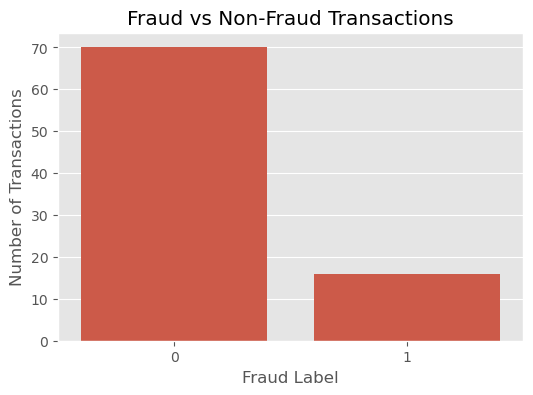

In [18]:
# Display Fraud Distribution using Bar Chart

plt.figure(figsize=(6,4))

sns.countplot(x="fraud_label", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Number of Transactions")

plt.show()

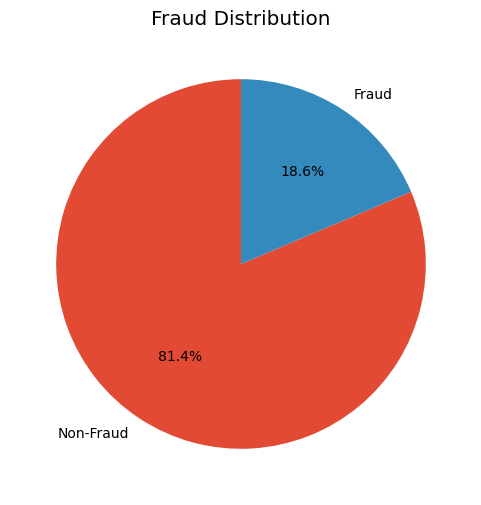

In [19]:
# Display Fraud Distribution using Pie Chart

fraud_count = df["fraud_label"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_count,
    labels=["Non-Fraud", "Fraud"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fraud Distribution")

plt.show()

### STEP-8 TRANSACTION AMOUNT ANALYSIS

In [20]:
## Basic statistics of Transaction Amount
print("=" * 60)
print("TRANSACTION AMOUNT STATISTICS")
print("=" * 60)

print("Minimum Transaction Amount :", df["transaction_amount"].min())

print("Maximum Transaction Amount :", df["transaction_amount"].max())

print("Average Transaction Amount :", round(df["transaction_amount"].mean(),2))

print("Median Transaction Amount :", df["transaction_amount"].median())

TRANSACTION AMOUNT STATISTICS
Minimum Transaction Amount : 500.0
Maximum Transaction Amount : 4000.0
Average Transaction Amount : 1623.43
Median Transaction Amount : 1375.0


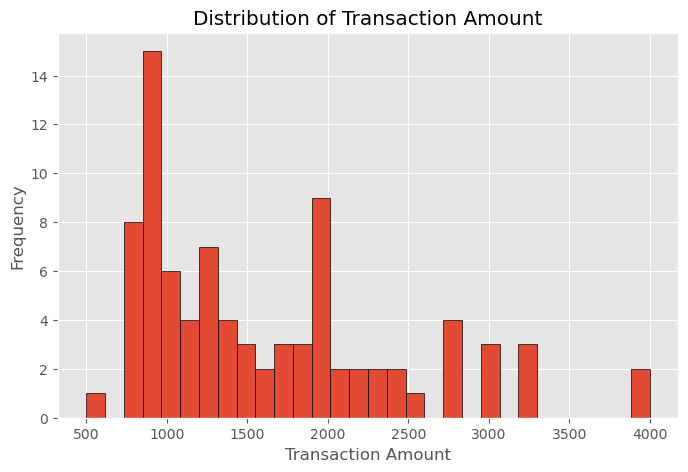

In [21]:
# Transaction Amount Distribution by Histogram

plt.figure(figsize=(8,5))

plt.hist(df["transaction_amount"], bins=30, edgecolor="black")

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

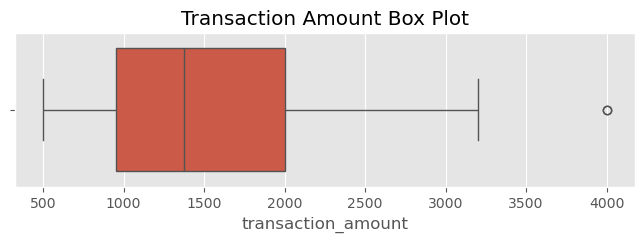

In [22]:
# Box Plot for Transaction Amount

plt.figure(figsize=(8,2))

sns.boxplot(x=df["transaction_amount"])

plt.title("Transaction Amount Box Plot")

plt.show()

### Fraud vs Transaction amount

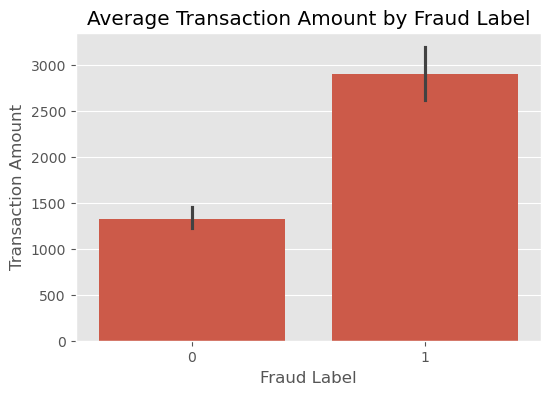

In [23]:
# Average Transaction Amount by Fraud Label

plt.figure(figsize=(6,4))

sns.barplot(
    x="fraud_label",
    y="transaction_amount",
    data=df
)

plt.title("Average Transaction Amount by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Amount")

plt.show()

### STEP-9 LOCATION WISE FRAUD ANALYSIS

In [24]:
## Location-wise Fraud Analysis
print("=" * 60)
print("FRAUD TRANSACTIONS BY LOCATION")
print("=" * 60)

fraud_location = df[df["fraud_label"] == 1]["location"].value_counts()

print(fraud_location)

FRAUD TRANSACTIONS BY LOCATION
location
San Francisco    8
Chicago          6
Los Angeles      1
New York         1
Name: count, dtype: int64


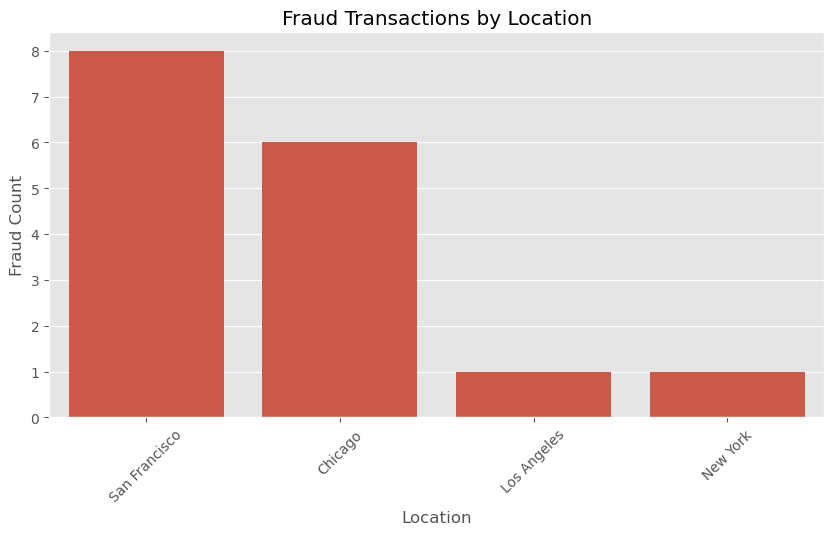

In [28]:
## Bar chart for location-wise fraud counts

plt.figure(figsize=(10,5))
sns.countplot(
    data=df[df["fraud_label"] == 1],
    x="location",
    order=df[df["fraud_label"] == 1]["location"].value_counts().index
)

plt.title("Fraud Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.show()

In [29]:
## Top 5 Locations with Highest Fraud

top_locations = fraud_location.head(5)

print("=" * 60)
print("TOP 5 FRAUD LOCATIONS")
print("=" * 60)

print(top_locations)

TOP 5 FRAUD LOCATIONS
location
San Francisco    8
Chicago          6
Los Angeles      1
New York         1
Name: count, dtype: int64


### 📘 STEP 10: Merchant-wise Fraud Analysis

In [30]:
## Fraud count by Merchant

print("=" * 60)
print("FRAUD TRANSACTIONS BY MERCHANT")
print("=" * 60)

fraud_merchant = df[df["fraud_label"] == 1]["merchant"].value_counts()

print(fraud_merchant)

FRAUD TRANSACTIONS BY MERCHANT
merchant
ABC Corp    10
XYZ Inc      6
Name: count, dtype: int64


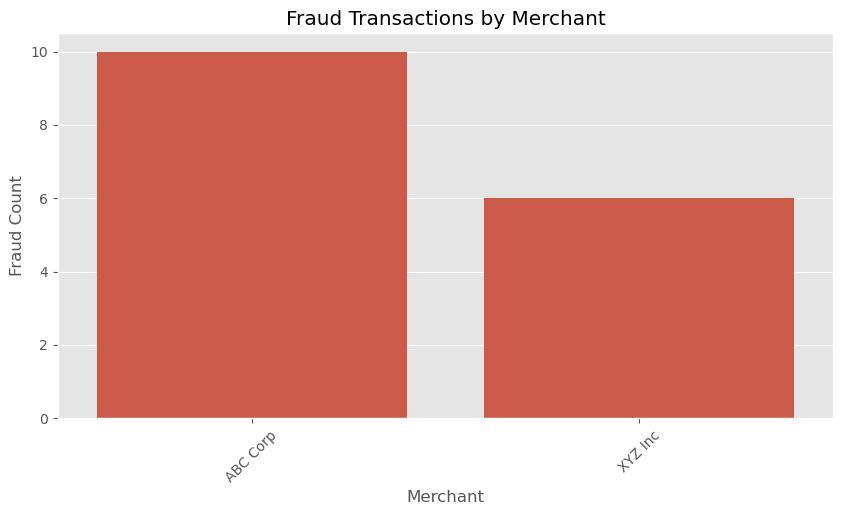

In [31]:
# Merchant-wise Fraud Count

plt.figure(figsize=(10,5))

sns.countplot(
    data=df[df["fraud_label"] == 1],
    x="merchant",
    order=df[df["fraud_label"] == 1]["merchant"].value_counts().index
)

plt.title("Fraud Transactions by Merchant")
plt.xlabel("Merchant")
plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.show()

In [32]:
# Top 5 Merchants with Highest Fraud

top_merchants = fraud_merchant.head(5)

print("=" * 60)
print("TOP 5 MERCHANTS WITH HIGHEST FRAUD")
print("=" * 60)

print(top_merchants)

TOP 5 MERCHANTS WITH HIGHEST FRAUD
merchant
ABC Corp    10
XYZ Inc      6
Name: count, dtype: int64


### 📘 STEP 11: Age-wise Fraud Analysis

In [33]:
## Age statistics 

print("=" * 60)
print("AGE STATISTICS")
print("=" * 60)

print("Minimum Age :", df["age"].min())
print("Maximum Age :", df["age"].max())
print("Average Age :", round(df["age"].mean(), 2))
print("Median Age :", df["age"].median())

AGE STATISTICS
Minimum Age : 26
Maximum Age : 56
Average Age : 40.08
Median Age : 39.5


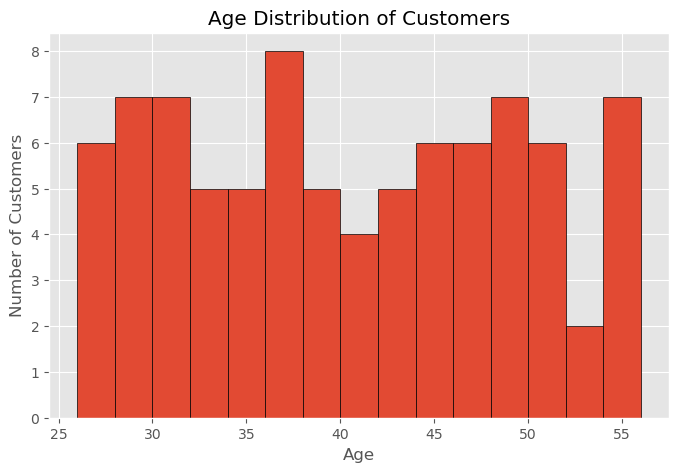

In [34]:
# Age Distribution

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=15, edgecolor="black")

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

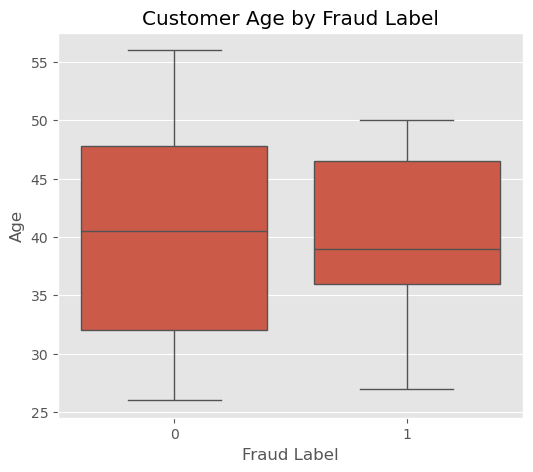

In [35]:
## Fraud label vs Age

plt.figure(figsize=(6,5))

sns.boxplot(
    x="fraud_label",
    y="age",
    data=df
)

plt.title("Customer Age by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Age")

plt.show()

### 📘 STEP 12: Gender-wise Fraud Analysis

In [ ]:
## Gender Count

print("=" * 60)
print("GENDER DISTRIBUTION")
print("=" * 60)

print(df["gender"].value_counts())

GENDER DISTRIBUTION
gender
M    43
F    43
Name: count, dtype: int64


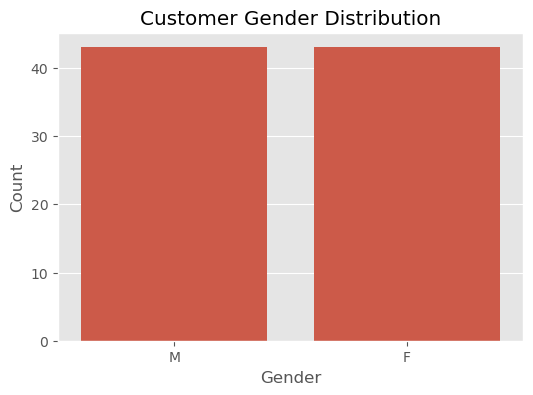

In [37]:
## Gender distribution chart

plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    data=df
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

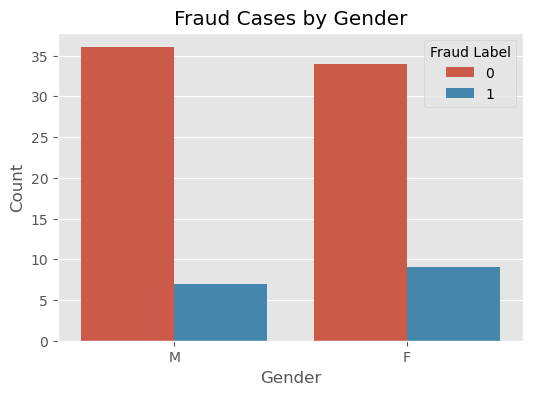

In [38]:
## Fraud by Gender

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="fraud_label"
)

plt.title("Fraud Cases by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Fraud Label")

plt.show()

### 📘 STEP 13: Correlation Analysis (Heatmap)

In [39]:
# Select only numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"])

# Calculate the correlation matrix
correlation_matrix = numerical_columns.corr()

# Display the correlation matrix
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

print(correlation_matrix)

CORRELATION MATRIX
                    transaction_id  transaction_amount       age  fraud_label
transaction_id            1.000000            0.048031  0.009045    -0.074628
transaction_amount        0.048031            1.000000 -0.096590     0.771904
age                       0.009045           -0.096590  1.000000    -0.021454
fraud_label              -0.074628            0.771904 -0.021454     1.000000


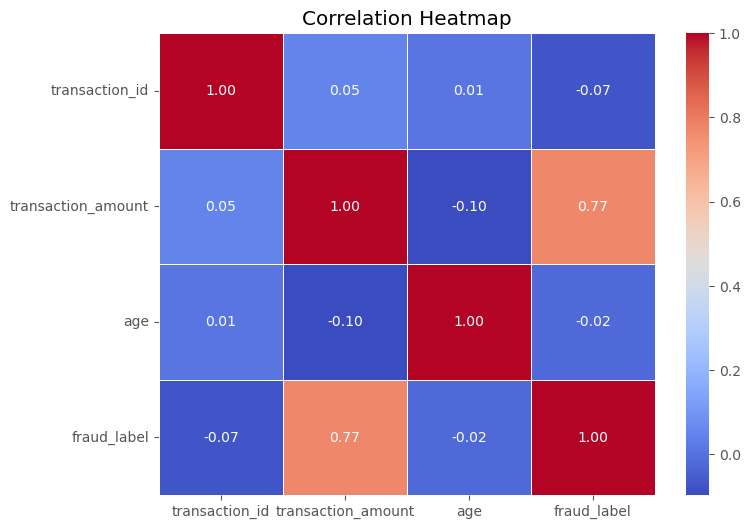

In [40]:
# VISUALIZE THE CORRELATION MATRIX

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### STEP-13 CORRELATION ANALYSIS

In [5]:

# Convert categorical columns to numbers
le = LabelEncoder()

for col in ['merchant', 'location', 'gender']:
    df[col] = le.fit_transform(df[col])

# Features (X)
X = df.drop(['fraud_label', 'transaction_id'], axis=1)

# Target (y)
y = df['fraud_label']

# Split data 
# MODIFICATION: Added stratify=y to ensure equal fraud distribution in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

# Train model 
# MODIFICATION: Added class_weight='balanced' to handle highly imbalanced fraud data
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred))


CONFUSION MATRIX
[[15  0]
 [ 0  3]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



### Observation 
- The heatmap shows the correlation between numerical variables.
- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values near 0 indicate little or no relationship.
- The fraud_label correlation with other numerical variables can help identify features that may be associated with fraudulent transactions.

### 📘 STEP 14: Business Insights

In [41]:
print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print("1. The dataset contains both fraudulent and genuine transactions.")
print()

print("2. Transaction amount analysis helps identify unusually high-value transactions.")
print()

print("3. Certain locations reported more fraudulent transactions than others.")
print()

print("4. Some merchants experienced a higher number of fraud cases.")
print()

print("5. Customer age distribution provides additional information about transaction patterns.")
print()

print("6. The correlation analysis shows the relationship between numerical variables.")
print()

print("7. These insights can help banks strengthen fraud detection and improve transaction monitoring.")

BUSINESS INSIGHTS
1. The dataset contains both fraudulent and genuine transactions.

2. Transaction amount analysis helps identify unusually high-value transactions.

3. Certain locations reported more fraudulent transactions than others.

4. Some merchants experienced a higher number of fraud cases.

5. Customer age distribution provides additional information about transaction patterns.

6. The correlation analysis shows the relationship between numerical variables.

7. These insights can help banks strengthen fraud detection and improve transaction monitoring.


### Observation

- Fraud is not evenly distributed across all transactions.
- High-value transactions require additional monitoring.
- Some locations and merchants experience more fraud than others.
- Correlation analysis helps understand relationships between numerical features.
- These findings can support banks in improving fraud prevention strategies.

### 📘 STEP 15: Conclusion

This project analyzed banking transaction data to identify fraud patterns using Python.

The analysis included:
- Data loading
- Data understanding
- Missing value analysis
- Duplicate value analysis
- Fraud distribution
- Transaction amount analysis
- Location-wise fraud analysis
- Merchant-wise fraud analysis
- Correlation analysis

The results provide useful insights that can help financial institutions monitor suspicious transactions and strengthen fraud prevention strategies.